# 1.2.2 内部交换与整体守恒

## 学习目标与先修知识

- 依据系统边界（system boundary）区分内部交换与外部转移。
- 从两个分区的收支（mass balance）得到整体收支。
- 说明总量不变不等于每个区域的状态（state）不变。

**先修知识**：[一段时间的物质收支](01-一段时间的物质收支.ipynb)；带符号加减与配对列表。

## 具体问题

把体内物质概括为血液区 B 与组织区 C。起点 B=5 U、C=2 U。一段时间中外界给 B 输入（input） 2 U，B 向 C 转移 3 U，C 向外界输出 1 U。注意这些量已经按时段累计，单位是 U。

先把每笔转移填到两本账上：同一笔内部交换，对 B 和 C 的符号是否相同？

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
first, second = 5, 2
incoming, transferred, outgoing = 2, 3, 1
display(Markdown(show_table(['事件', 'B 的变化 / U', 'C 的变化 / U', '整体变化 / U'],
    [('外部输入', 2, 0, 2), ('内部交换', -3, 3, 0), ('外部输出', 0, -1, -1)])))

| 事件 | B 的变化 / U | C 的变化 / U | 整体变化 / U |
| --- | --- | --- | --- |
| 外部输入 | 2 | 0 | 2 |
| 内部交换 | -3 | 3 | 0 |
| 外部输出 | 0 | -1 | -1 |

## 模型假设

假设两区都用同一种所追踪物质总量（tracked amount）单位，没有内部生成或转化，也没有漏记的跨边界通道。本节不预测转移速率，只给定每段已经发生的转移量。

| 符号 | 解释 | 单位 |
|---|---|---|
| B、C | 每段开始或结束时两区的存量（stock） | U |
| I | 本段从外界进入 B 的量 | U |
| X | 本段从 B 转入 C 的量 | U |
| O | 本段从 C 离开整体的量 | U |

只看 B，X 是输出；合并 B+C 后，X 完全发生在系统内部。改变边界不改变事件，却改变这件事在账本中的分类。

## 数学解释与推导

把两本账相加：

$$B_{\text{末}}=B_{\text{初}}+I-X,\qquad C_{\text{末}}=C_{\text{初}}+X-O.$$

内部转移的 $-X$ 与 $+X$ 恰好抵消，所以

$$(B+C)_\mathrm{末}=(B+C)_\mathrm{初}+I-O.$$

这不是另加一个假设，而是相同转移在两边记账的代数结果。第一段 B=4、C=4，整体从 7 到 8，只增加 1 U。若把 X 再当作整体损失，就重复扣除了物质。

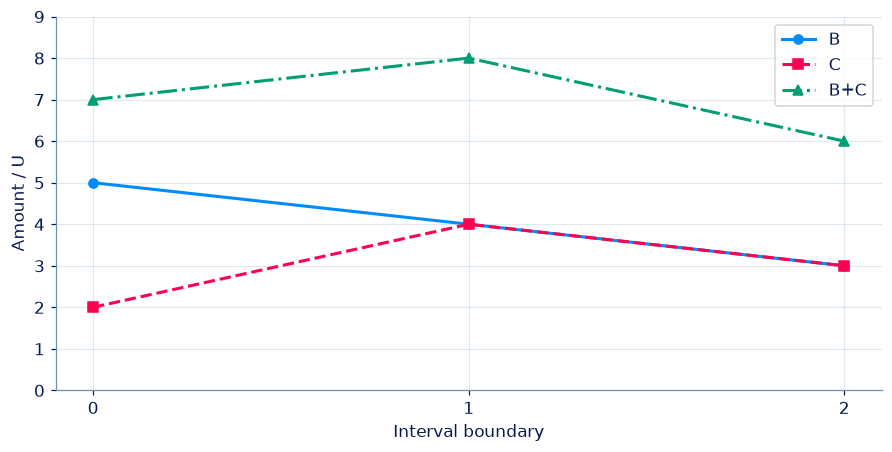

In [2]:
def two_regions(first, second, incoming, transferred, outgoing):
    b, c = [first], [second]
    for i, x, o in zip(incoming, transferred, outgoing):
        b.append(b[-1]+i-x)
        c.append(c[-1]+x-o)
    return b, c

b, c = two_regions(5, 2, [2, 0], [3, 1], [1, 2])
total = [x+y for x,y in zip(b,c)]
assert b == [5, 4, 3] and c == [2, 4, 3] and total == [7, 8, 6]
fig, ax = plt.subplots()
for path, marker, style, label in [(b,'o','-','B'), (c,'s','--','C'), (total,'^','-.','B+C')]:
    ax.plot(range(3), path, marker=marker, linestyle=style, label=label)
ax.set(xlabel='Interval boundary', ylabel='Amount / U', xticks=range(3), ylim=(0,9))
ax.legend()
plt.show()

## 对照实验

保持起点、外部输入和输出不变，把内部转移从 [3,1] 改为 [1,1]。两个分区会变，总量是否也会变？再令外部输入、输出都为零，观察封闭系统。

In [3]:
b2, c2 = two_regions(5, 2, [2, 0], [1, 1], [1, 2])
assert [x+y for x,y in zip(b2,c2)] == total
direct_total = [7, 7+2-1, 7+2-1+0-2]
assert total == direct_total
closed_b, closed_c = two_regions(5, 0, [0,0], [2,3], [0,0])
assert [x+y for x,y in zip(closed_b,closed_c)] == [5,5,5]
display(Markdown(show_table(['时刻序号', '封闭 B / U', '封闭 C / U'], zip(range(3),closed_b,closed_c))))

| 时刻序号 | 封闭 B / U | 封闭 C / U |
| --- | --- | --- |
| 0 | 5 | 0 |
| 1 | 3 | 2 |
| 2 | 0 | 5 |

## 结果解释

内部交换方式决定物质在哪里，而整体收支只取决于穿过联合边界的量。总量恒定时，局部分布仍能显著改变；测总量不足以恢复所有内部状态。

如果追踪的是细胞数量，分裂会增加细胞数；如果追踪一种化学物种，内部转化也可能生成或消耗它。因此“守恒”必须说明追踪的对象与过程，不能把总量账目无条件套到所有计数量上。

[打开可视化与探索：存量流量与守恒](http://127.0.0.1:8000/chapters/01-02-存量、流量与守恒/explore/)

[本章导览](http://127.0.0.1:8000/chapters/01-02-存量、流量与守恒/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：扩大边界后什么抵消

血液室 B 向组织室 C 转移 3 U，外界向 B 输入（input） 2 U，C 向外界排出 1 U。没有其他变化。关于物质收支（mass balance），哪些结论正确？

- **A.** B 改变 −1 U。
- **B.** C 改变 +2 U。
- **C.** B+C 改变 +1 U。
- **D.** B+C 改变 −2 U，因为还要减去内部转移 3 U。

[作答：扩大边界后什么抵消](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-internal-transfer)

### 第 2 题 · Python 计算题：两个房间，一本总账

一个细胞物质被分在 B、C 两个区域。每段给定的是已经累计的外部输入（input）、B 到 C 内部转移和外部输出，均为 U，不是速率。返回两区及总量轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    first: float,
    second: float,
    incoming: list[float],
    transferred: list[float],
    outgoing: list[float],
) -> tuple[list[float], list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `first` | `float` | B 区初始所追踪物质总量（tracked amount）。 | U |
| `second` | `float` | C 区初始总量。 | U |
| `incoming` | `list[float]` | 每段从外界进入 B 的量。 | U |
| `transferred` | `list[float]` | 每段从 B 转入 C 的量。 | U |
| `outgoing` | `list[float]` | 每段从 C 离开整体的量。 | U |

**返回值**

按以下顺序返回元组：(first_path, second_path, total_path)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `first_path` | `list[float]` | B 的轨迹，包含初值（initial condition）。 | U |
| `second_path` | `list[float]` | C 的轨迹，包含初值。 | U |
| `total_path` | `list[float]` | 对应时刻 B+C，包含初值。 | U |

**计算规则**

逐段更新 B = B + incoming[i] − transferred[i]，C = C + transferred[i] − outgoing[i]。内部转移只记一次流出 B 和一次流入 C。

**约束与边界**

- 所有数值均为有限数。
- 三个列表等长，长度 0 到 1000；各输入值在 0 到 1000 之间。
- 给定数据保证各段末两区均非负；返回三个列表，长度都是段数加一。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| first | B 区初始所追踪物质总量（tracked amount）。 | 5 | U |
| second | C 区初始总量。 | 2 | U |
| incoming | 每段从外界进入 B 的量。 | [2, 0] | U |
| transferred | 每段从 B 转入 C 的量。 | [3, 1] | U |
| outgoing | 每段从 C 离开整体的量。 | [1, 2] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
first = 5
second = 2
incoming = [2, 0]
transferred = [3, 1]
outgoing = [1, 2]

result = solve(first, second, incoming, transferred, outgoing)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| first_path | B 的轨迹，包含初值（initial condition）。 | [5, 4, 3] | U |
| second_path | C 的轨迹，包含初值。 | [2, 4, 3] | U |
| total_path | 对应时刻 B+C，包含初值。 | [7, 8, 6] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([5, 4, 3], [2, 4, 3], [7, 8, 6])
```

**样例解释**

第一段 B 为 5+2−3=4，C 为 2+3−1=4，总量为 8；第二段总量只因向外输出 2 U 而减至 6。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：两个房间，一本总账](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-two-rooms)

### 第 3 题 · 单项选择题：守恒需要说清所追踪的对象

若某种物质能在边界内由另一种物质生成，下列哪项最准确？

- **A.** 该物质的增加只能来自跨边界流入。
- **B.** 所追踪的单一物质需要生成项；不能把漏掉的生成误认成外界输入（input）。
- **C.** 任何边界内的物质数量都永远不变。
- **D.** 只要总量增加，就一定发生了计数错误。

[作答：守恒需要说清所追踪的对象](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-hidden-production)

### 第 4 题 · 多项选择题：总量不变能推出什么

一个封闭的两区模型（model）只允许内部物质转移。观测（observation）到 B 减少 3 U，C 增加 3 U。哪些判断合理？

- **A.** 联合存量（stock）不变。
- **B.** 两区各自的状态（state）都不变。
- **C.** 这一结果与内部转移相容，但仅凭端点不能确认全过程只有这一种机制。
- **D.** 可以在联合收支（mass balance）中把这 3 U 再计为外部输入（input）。

[作答：总量不变能推出什么](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-conserved-total)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。